c:\Users\azeb.mehrete\Documents\KAIM\KAIM-9\w9env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.0064 - val_loss: 0.0026
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 7.9556e-04 - val_loss: 0.0024
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 7.2227e-04 - val_loss: 0.0021
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.9045e-04 - val_loss: 0.0020
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.7938e-04 - val_loss: 0.0019
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 6.1883e-04 - val_loss: 0.0023
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 5.0792e-04 - val_loss: 0.0017
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 4.7473e-04 - val_loss: 0.0015
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 4.6347e-04 - val_loss: 0.0013
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 4.2648e-04 - val_loss: 0.0016
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 4.3445e-04 - val_loss: 0.0012
Epoch 12/30
70/70 ━━━━━

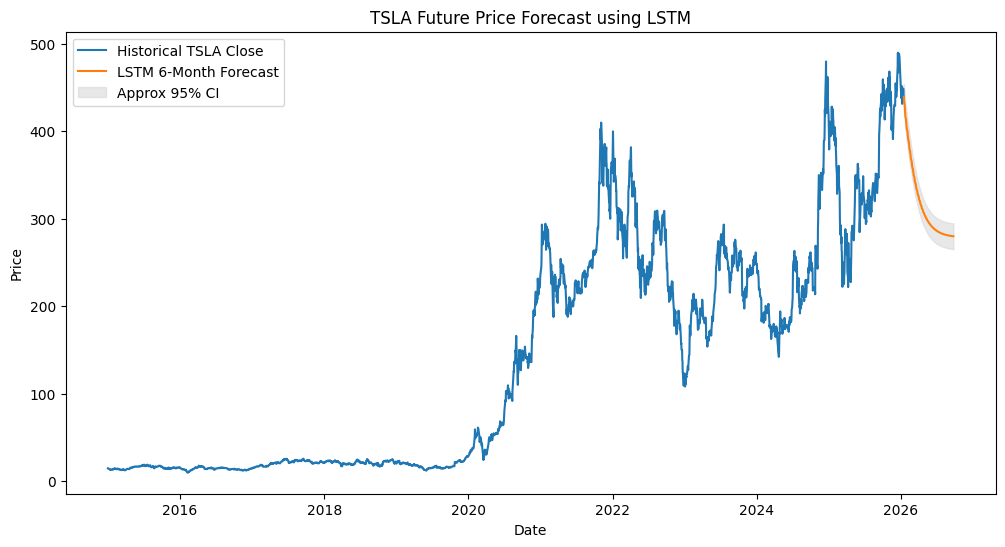

Forecast sample:
2026-01-15    439.485718
2026-01-16    435.173584
2026-01-19    431.047943
2026-01-20    427.056366
2026-01-21    423.273926
Freq: B, dtype: float32

Confidence Intervals sample:
Upper: 2026-01-15    454.198547
2026-01-16    449.886414
2026-01-19    445.760773
2026-01-20    441.769196
2026-01-21    437.986755
Freq: B, dtype: float32
Lower: 2026-01-15    424.772888
2026-01-16    420.460754
2026-01-19    416.335114
2026-01-20    412.343536
2026-01-21    408.561096
Freq: B, dtype: float32


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- Load and prepare TSLA indexed data ---
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_tsla["Close"] = pd.to_numeric(df_tsla["Close"], errors="coerce")
df_tsla = df_tsla.dropna(subset=["Close"])

tsla_series = df_tsla["Close"].astype(float)

# --- Chronological split ---
train = tsla_series[: "2024-12-31"]
test  = tsla_series["2025-01-01":]

# --- Scaling ---
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(tsla_series.values.reshape(-1,1))

# --- Create sequences function ---
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 60
X_all, y_all = create_sequences(scaled_series, window)

# --- Train/test LSTM splits ---
train_size = len(train) - window
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# --- Build and train LSTM model ---
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mean_squared_error")

history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# --- Recursive multi-step future forecast (e.g., 180 business days) ---
future_horizon = 180
last_seq = scaled_series[-window:].flatten()
future_scaled = []

current_seq = last_seq.copy()
for _ in range(future_horizon):
    x_in = current_seq.reshape(1, window, 1)
    scaled_pred = lstm_model.predict(x_in)
    future_scaled.append(scaled_pred[0,0])
    current_seq = np.append(current_seq[1:], scaled_pred[0,0])

future_scaled = np.array(future_scaled).reshape(-1,1)
future_preds = scaler.inverse_transform(future_scaled).flatten()

# --- Build future date index ---
last_date = df_tsla.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=future_horizon)

future_series = pd.Series(future_preds, index=future_dates)

# --- Compute approximate confidence intervals ---
# residuals from training
train_pred = lstm_model.predict(X_train).flatten()
train_true = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
residuals = train_true - scaler.inverse_transform(train_pred.reshape(-1,1)).flatten()

resid_std = np.std(residuals)
ci_upper = future_series + 1.96 * resid_std
ci_lower = future_series - 1.96 * resid_std

# --- Plot forecast with confidence intervals ---
plt.figure(figsize=(12,6))
plt.plot(tsla_series, label="Historical TSLA Close")
plt.plot(future_series, label="LSTM 6-Month Forecast")
plt.fill_between(future_series.index, ci_lower, ci_upper, color="lightgray", alpha=0.5, label="Approx 95% CI")
plt.title("TSLA Future Price Forecast using LSTM")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# --- Print sample of forecast results ---
print("Forecast sample:")
print(future_series.head())
print("\nConfidence Intervals sample:")
print("Upper:", ci_upper.head())
print("Lower:", ci_lower.head())


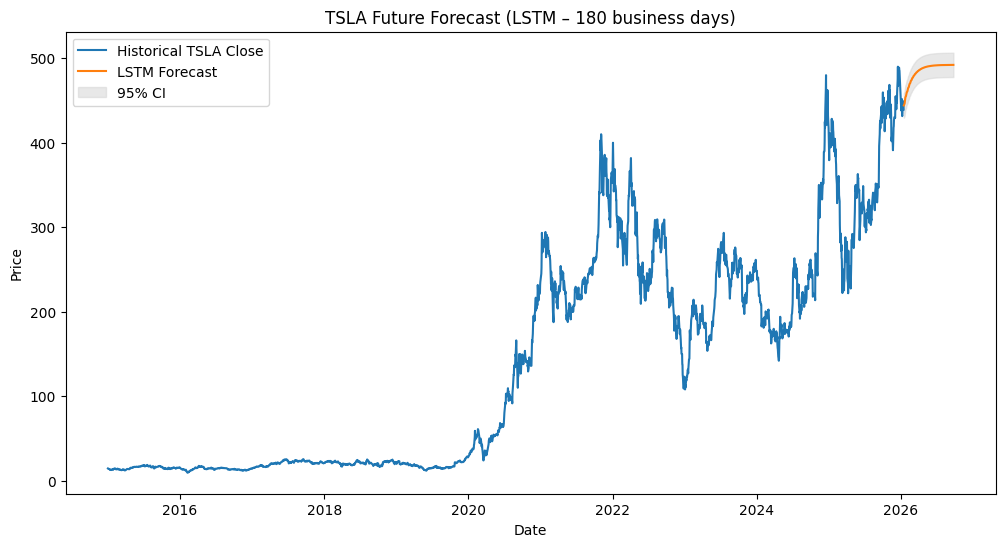

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_tsla["Close"], label="Historical TSLA Close")
plt.plot(future_series, label="LSTM Forecast")
plt.fill_between(future_series.index, ci_lower, ci_upper, color="lightgray", alpha=0.5, label="95% CI")
plt.title("TSLA Future Forecast (LSTM – 180 business days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()
